> 공식 문서: <https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/#research-agent>

### 3. Create supervisor from scratch

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_core.tools import tool
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_community.tools import DuckDuckGoSearchResults 

@tool
def get_web_search(query: str, search_period: str='w') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        region="kr-kr",
        time=search_period
    )

    print('\n----- WEB SEARCH -----')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

In [3]:
from langgraph.prebuilt import create_react_agent

research_agent = create_react_agent(
    model="google_genai:gemini-2.5-flash",
    tools=[get_web_search],
    prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, DO NOT do any math\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="research_agent",
)

In [4]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

In [5]:
for chunk in research_agent.stream(
    {"messages": [{"role": "user", "content": "who is the mayor of NYC?"}]}
):
    pretty_print_messages(chunk)

Update from node agent:


================================== Ai Message ==================================
Name: research_agent
Tool Calls:
  get_web_search (8f66b7b2-0568-43f8-b71e-6a7539ebd8b0)
 Call ID: 8f66b7b2-0568-43f8-b71e-6a7539ebd8b0
  Args:
    query: mayor of NYC



----- WEB SEARCH -----
mayor of NYC
w
1. snippet: Here's where each of the candidates stands on Rikers Island's future. amNY Your Vote: Where does the next NYC mayor stand on the future of Rikers., title: amny, link: https://www.facebook.com/amnewyork/?locale=ko_KR
2. snippet: ... Mayor Eric Adams . 4 people including a NYC police officer were killed in the shooting . Tamura played High school Football in California a decade ago but ..., title: 🚨 According to a statement from The New York City Office ..., link: https://www.facebook.com/TMZ/posts/-according-to-a-statement-from-the-new-york-city-office-of-chief-medical-examine/1215719510590148/?locale=ko_KR
3. snippet: 4일 전 — 미국의 검사 출신 정치인. 1994년부터 2001년까지 제 107대 뉴

In [6]:
def add(a: float, b: float):
    """Add two numbers."""
    return a + b


def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b


def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b


math_agent = create_react_agent(
    model="google_genai:gemini-2.5-flash",
    tools=[add, multiply, divide],
    prompt=(
        "You are a math agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="math_agent",
)

In [7]:
for chunk in math_agent.stream(
    {"messages": [{"role": "user", "content": "what's (3 + 5) x 7"}]}
):
    pretty_print_messages(chunk)

Update from node agent:


================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  add (28071c3b-a12e-42fb-9151-7b25bde215e1)
 Call ID: 28071c3b-a12e-42fb-9151-7b25bde215e1
  Args:
    b: 5
    a: 3


Update from node tools:


================================= Tool Message =================================
Name: add

8.0


Update from node agent:


================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  multiply (94b805da-1680-43d2-9a24-81e6a5129f1b)
 Call ID: 94b805da-1680-43d2-9a24-81e6a5129f1b
  Args:
    b: 7
    a: 8


Update from node tools:


================================= Tool Message =================================
Name: multiply

56.0


Update from node agent:


================================== Ai Message ==================================
Name: math_agent

56




In [8]:
from typing import Annotated
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.types import Command


def create_handoff_tool(*, agent_name: str, description: str | None = None):
    name = f"transfer_to_{agent_name}"
    description = description or f"Ask {agent_name} for help."

    @tool(name, description=description)
    def handoff_tool(
        state: Annotated[MessagesState, InjectedState],
        tool_call_id: Annotated[str, InjectedToolCallId],
    ) -> Command:
        tool_message = {
            "role": "tool",
            "content": f"Successfully transferred to {agent_name}",
            "name": name,
            "tool_call_id": tool_call_id,
        }
        return Command(
            goto=agent_name,  
            update={**state, "messages": state["messages"] + [tool_message]},  
            graph=Command.PARENT,  
        )

    return handoff_tool


# Handoffs
assign_to_research_agent = create_handoff_tool(
    agent_name="research_agent",
    description="Assign task to a researcher agent.",
)

assign_to_math_agent = create_handoff_tool(
    agent_name="math_agent",
    description="Assign task to a math agent.",
)

In [9]:
supervisor_agent = create_react_agent(
    model="google_genai:gemini-2.5-flash",
    tools=[assign_to_research_agent, assign_to_math_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n"
        "- a math agent. Assign math-related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    name="supervisor",
)

In [10]:
from langgraph.graph import END

# Define the multi-agent supervisor graph
supervisor = (
    StateGraph(MessagesState)
    # NOTE: `destinations` is only needed for visualization and doesn't affect runtime behavior
    .add_node(supervisor_agent, destinations=("research_agent", "math_agent", END))
    .add_node(research_agent)
    .add_node(math_agent)
    .add_edge(START, "supervisor")
    # always return back to the supervisor
    .add_edge("research_agent", "supervisor")
    .add_edge("math_agent", "supervisor")
    .compile()
)

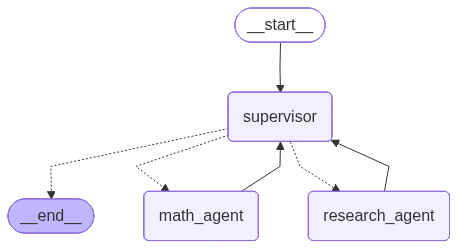

In [11]:
from IPython.display import display, Image

display(Image(supervisor.get_graph().draw_mermaid_png()))

In [13]:
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "find US and New York state GDP in 2024. what % of US GDP was New York state?",
            }
        ]
    },
):
    pretty_print_messages(chunk, last_message=True)

final_message_history = chunk["supervisor"]["messages"]

Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent



----- WEB SEARCH -----
US GDP 2024
w

----- WEB SEARCH -----
New York state GDP 2024
w
1. snippet: 3일 전 — ... York State 또는 Upstate New York 이라고 하지 뉴욕 은 New York 일 뿐이다. NYC로 ... 2022년 뉴욕 광역권의 GDP 는 2조 5,300억 달러에 달하는 수준이며 1인당 GDP ..., title: 뉴욕시, link: https://namu.wiki/w/뉴욕시
2. snippet: 2일 전 — 경제 규모 (PPP). 29조 1,678억 달러 (약 4경 593조 원). 2024 년[2], 세계 2위 ; 연간 GDP 성장률. 2.8%. 2024 년[3] ; 1인당 명목 GDP . 86,601 달러. 2024 년, 세계 5위 ; 1 ..., title: 미국/경제, link: https://namu.wiki/w/미국/경제
3. snippet: 5일 전 — As of 2024 , it accounts for 44% of nominal GDP and 65% of total employment. Nevertheless, labor productivity in the private service sector has stagnated at ..., title: 한국은행, link: https://www.bok.or.kr/portal/bbs/B0000354/view.do?menuNo=400409&nttId=10093636
4. snippet: 4일 전 — 2024 년 기준 FIRE 부문의 GDP 비중은 미국이 